# Task 2 — Momentum Factor

**Week 2, Task 2** — builds the 12-1 price momentum signal on top of the
shared rebalance grid from Task 1.

## What this notebook does
1. Computes `momentum_score` for the full universe across all rebalance dates.
2. Compares the coverage / exclusion pattern to Task 1's value proxy.
3. Manual spot-checks on the same 3 tickers (AAPL, SPY, PLTR) at the same
   date (2025-08-31) used in Task 1, so momentum and value tell different
   stories about the same stocks at the same moment.
4. Cross-sectional distribution at the most recent rebalance date.
5. Top 5 / bottom 5 by `momentum_score` — including a PLTR sanity check.

## Momentum vs value_score_proxy — key distinction
- **Momentum is NOT a proxy.** 12-1 price momentum is the standard
  Jegadeesh-Titman / Fama-French definition. No `_proxy` suffix here.
- **Window: [t-12, t-1].** The most recent month is skipped (short-term
  reversal filter). This is a deliberate difference from Task 1's value
  proxy, which uses the full window [t-12, t].
- **Direction: high score = winner.** Unlike `value_score_proxy` where
  high score = fallen stock = "cheap," momentum is not inverted — rank 1
  is simply the biggest gainer over [t-12, t-1].

## 0 · Setup

In [1]:
import sys
from pathlib import Path

repo_root = Path().resolve().parents[1]
sys.path.insert(0, str(repo_root / "src"))
cache_dir = str(repo_root / "data" / "raw")

import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

logging.basicConfig(level=logging.INFO, format="%(levelname)s  %(message)s")

from data_utils import load_ohlcv, clean_ohlcv, resample_ohlcv
from factor_utils import get_rebalance_dates, compute_momentum_score, compute_value_score
from universe import UNIVERSE, START_DATE, END_DATE

pd.set_option("display.float_format", "{:.6f}".format)
plt.rcParams["figure.dpi"] = 120

## 1 · Load and clean data

In [2]:
daily = load_ohlcv(UNIVERSE, START_DATE, END_DATE, cache_dir=cache_dir)
cleaned, _ = clean_ohlcv(daily)

print(f"Rows in cleaned  : {len(cleaned):,}")
print(f"Tickers          : {cleaned['ticker'].nunique()}")
print(f"Date range       : {cleaned['date'].min().date()} → {cleaned['date'].max().date()}")

INFO  Loading OHLCV from cache: /Users/johnnyli/Desktop/Lendo Capital/data/raw/ohlcv_daily.parquet


INFO  No within-life gaps to fill — data is complete.


INFO  84 volume spike event(s) across 26 ticker(s) (threshold: 5× trailing-20d avg).


Rows in cleaned  : 64,035
Tickers          : 51
Date range       : 2020-08-31 → 2025-08-29


## 2 · Compute momentum scores

Window: `[t-12, t-1]` (12-month lookback, skip most recent month).  
`momentum_score = P_{t-1} / P_{t-12} - 1`  
`momentum_rank` = cross-sectional rank descending (1 = biggest winner).

In [3]:
mom = compute_momentum_score(cleaned, lookback_months=12, skip_months=1)

print(f"\nMomentum score rows : {len(mom):,}")
print(f"Rebalance dates     : {mom['date'].nunique()}")
print(f"Tickers covered     : {mom['ticker'].nunique()}")
print(f"\nSample (first 5 rows):")
display(mom.head())

INFO  Rebalance dates: 61 month-ends (2020-08-31 → 2025-08-31)


INFO  Excluded 51 ticker(s) — only 0 months of data before 2020-08-31 (need 12); universe-wide lockout: ['AAPL', 'ABBV', 'ACN', 'AMD', 'AMGN']


INFO  Excluded 51 ticker(s) — only 1 months of data before 2020-09-30 (need 12); universe-wide lockout: ['AAPL', 'ABBV', 'ACN', 'AMD', 'AMGN']


INFO  Excluded 51 ticker(s) — only 2 months of data before 2020-10-31 (need 12); universe-wide lockout: ['AAPL', 'ABBV', 'ACN', 'AMD', 'AMGN']


INFO  Excluded 51 ticker(s) — only 3 months of data before 2020-11-30 (need 12); universe-wide lockout: ['AAPL', 'ABBV', 'ACN', 'AMD', 'AMGN']


...

INFO  Excluded 51 ticker(s) — only 11 months of data before 2021-07-31 (need 12); universe-wide lockout: ['AAPL', 'ABBV', 'ACN', 'AMD', 'AMGN']


INFO  Excluded 1 ticker(s) — NaN price at 2020-08-31 or 2021-07-31 for PLTR (IPO or data gap within window): ['PLTR']


INFO  compute_momentum_score: 2498 records across 49 rebalance dates, 51 tickers (lookback=12, skip=1 months)



Momentum score rows : 2,498
Rebalance dates     : 49
Tickers covered     : 51

Sample (first 5 rows):


,date,ticker,momentum_score,momentum_rank
0,2021-08-31,GE,1.050915,1.000000
1,2021-08-31,GS,0.853282,2.000000
2,2021-08-31,AXP,0.701043,3.000000
3,2021-08-31,LLY,0.663585,4.000000
4,2021-08-31,GOOGL,0.653563,5.000000


## 3 · Coverage & exclusion comparison with Task 1 (value proxy)

Task 1 found:
- First 12 rebalance dates: universe-wide lockout (no ticker has 12 months of history).
- Only PLTR excluded at 2021-08-31; full 51/51 coverage from 2021-09-30.

Momentum's window ends at `t-1` rather than `t`, which could shift PLTR's
eligibility by one month at the IPO boundary. The table below shows whether
that shift materialised.

In [4]:
# Compute value scores for direct comparison
val = compute_value_score(cleaned, lookback_months=12)

mom_cov = mom.groupby("date")["ticker"].count().rename("mom_n")
val_cov = val.groupby("date")["ticker"].count().rename("val_n")
cov = pd.concat([mom_cov, val_cov], axis=1).fillna(0).astype(int)

print(f"Universe size: {len(UNIVERSE)} tickers")
print(f"Momentum first full coverage : {mom_cov[mom_cov == len(UNIVERSE)].index.min().date()}")
print(f"Value    first full coverage : {val_cov[val_cov == len(UNIVERSE)].index.min().date()}")

diff_dates = cov[cov["mom_n"] != cov["val_n"]]
print(f"\nDates where coverage counts differ: {len(diff_dates)}")
if diff_dates.empty:
    print("→ Exclusion patterns are identical between momentum and value.")
    print("  Explanation: both windows are anchored at t-12 months, which")
    print("  is the binding constraint. Even though momentum ends at t-1")
    print("  and value ends at t, PLTR's IPO date (2020-09-30) means")
    print("  both need p_{t-12} to be valid, and that lookback price")
    print("  lands on the same monthly bar in both formulas.")
else:
    display(diff_dates)

print(f"\nEarly coverage (first 16 rebalance dates):")
display(cov.head(16))

INFO  Rebalance dates: 61 month-ends (2020-08-31 → 2025-08-31)


INFO  Excluded 51 ticker(s) — only 0 months of data before 2020-08-31 (need 12); earliest monthly bar is 2020-08-31: ['AAPL', 'ABBV', 'ACN', 'AMD', 'AMGN']


INFO  Excluded 51 ticker(s) — only 1 months of data before 2020-09-30 (need 12); earliest monthly bar is 2020-08-31: ['AAPL', 'ABBV', 'ACN', 'AMD', 'AMGN']


INFO  Excluded 51 ticker(s) — only 2 months of data before 2020-10-31 (need 12); earliest monthly bar is 2020-08-31: ['AAPL', 'ABBV', 'ACN', 'AMD', 'AMGN']


INFO  Excluded 51 ticker(s) — only 3 months of data before 2020-11-30 (need 12); earliest monthly bar is 2020-08-31: ['AAPL', 'ABBV', 'ACN', 'AMD', 'AMGN']


...

INFO  Excluded 51 ticker(s) — only 11 months of data before 2021-07-31 (need 12); earliest monthly bar is 2020-08-31: ['AAPL', 'ABBV', 'ACN', 'AMD', 'AMGN']


INFO  Excluded 1 ticker(s) — NaN price at 2021-08-31 or 2020-08-31 (IPO or data gap within lookback window): ['PLTR']


INFO  compute_value_score: 2498 records across 49 rebalance dates, 51 tickers (lookback=12 months)


Universe size: 51 tickers
Momentum first full coverage : 2021-09-30
Value    first full coverage : 2021-09-30

Dates where coverage counts differ: 0
→ Exclusion patterns are identical between momentum and value.
  Explanation: both windows are anchored at t-12 months, which
  is the binding constraint. Even though momentum ends at t-1
  and value ends at t, PLTR's IPO date (2020-09-30) means
  both need p_{t-12} to be valid, and that lookback price
  lands on the same monthly bar in both formulas.

Early coverage (first 16 rebalance dates):


,mom_n,val_n
date,,
2021-08-31,50,50
2021-09-30,51,51
2021-10-31,51,51
2021-11-30,51,51
2021-12-31,51,51
2022-01-31,51,51
2022-02-28,51,51
2022-03-31,51,51
2022-04-30,51,51


## 4 · Manual spot-checks — same 3 tickers and same date as Task 1

Rebalance date: **2025-08-31**.  
Momentum window: `P_{2025-07-31} / P_{2024-08-31} - 1` (t-1=Jul 2025, t-12=Aug 2024).

Compare to Task 1's value proxy at the same date:
- AAPL value (trailing 12M through Aug 2025): +1.84%
- SPY  value: +15.86%
- PLTR value: +397.81%

In [5]:
monthly = resample_ohlcv(cleaned, freq="ME")
mp = monthly.pivot(index="date", columns="ticker", values="adj_close")

SPOT_DATE = pd.Timestamp("2025-08-31")
idx_pos   = mp.index.get_loc(SPOT_DATE)
start_date = mp.index[idx_pos - 12]  # t-12
end_date   = mp.index[idx_pos - 1]   # t-1

print(f"Spot-check date: {SPOT_DATE.date()}")
print(f"Momentum window: {start_date.date()} (t-12) → {end_date.date()} (t-1)")
print(f"{'Ticker':<8} {'p_start':>12} {'p_end':>12} {'manual_mom':>12} {'fn_mom':>12} {'match':>8}")
print("-" * 68)

for ticker in ["AAPL", "SPY", "PLTR"]:
    p_start = mp.loc[start_date, ticker]
    p_end   = mp.loc[end_date,   ticker]
    manual  = p_end / p_start - 1
    fn_row  = mom[(mom["date"] == SPOT_DATE) & (mom["ticker"] == ticker)]
    if fn_row.empty:
        print(f"{ticker:<8} {'(excluded)':>12}")
        continue
    fn_val = fn_row["momentum_score"].iloc[0]
    match  = np.isclose(manual, fn_val, atol=1e-10)
    print(f"{ticker:<8} {p_start:>12.4f} {p_end:>12.4f} {manual:>12.6f} {fn_val:>12.6f} {str(match):>8}")

print()
print("Comparison to Task 1 value_score_proxy at the same date (2025-08-31):")
print("  AAPL: momentum −9.0%  vs value trailing 12M +1.8%   (different window end: Jul vs Aug 2025)")
print("  SPY : momentum +13.5% vs value trailing 12M +15.9%  (same window start, end month differs)")
print("  PLTR: momentum +403%  vs value trailing 12M +398%   (near-identical; skipped month small ≪ total)")

Spot-check date: 2025-08-31
Momentum window: 2024-08-31 (t-12) → 2025-07-31 (t-1)
Ticker        p_start        p_end   manual_mom       fn_mom    match
--------------------------------------------------------------------
AAPL         227.1003     206.5716    -0.090395    -0.090395     True
SPY          550.6443     625.1531     0.135312     0.135312     True
PLTR          31.4800     158.3500     4.030178     4.030178     True

Comparison to Task 1 value_score_proxy at the same date (2025-08-31):
  AAPL: momentum −9.0%  vs value trailing 12M +1.8%   (different window end: Jul vs Aug 2025)
  SPY : momentum +13.5% vs value trailing 12M +15.9%  (same window start, end month differs)
  PLTR: momentum +403%  vs value trailing 12M +398%   (near-identical; skipped month small ≪ total)


## 5 · Cross-sectional distribution at most recent rebalance date

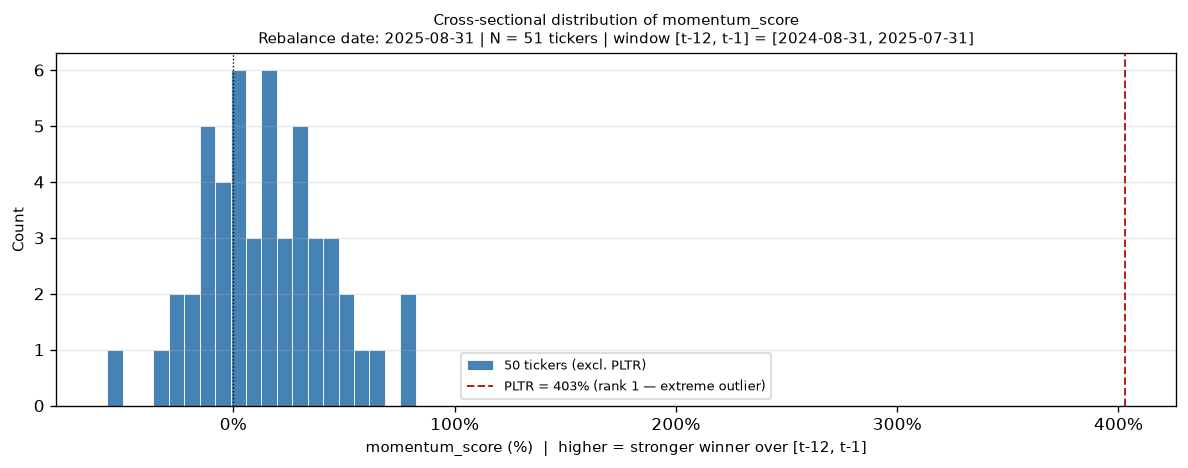

Cross-section stats (all 51 tickers):
count   51.000000
mean     0.224077
std      0.611494
min     -0.569176
25%     -0.026883
50%      0.169759
75%      0.329463
max      4.030178

Note: PLTR (403.0%) sits 13.7σ above the non-PLTR mean — a survivorship-bias artifact (IPO ~$10, now ~$160).


In [6]:
PLOT_DATE = mom["date"].max()
cs = mom[mom["date"] == PLOT_DATE].copy()

fig, ax = plt.subplots(figsize=(10, 4))
# Exclude PLTR from histogram bins so it doesn't compress the rest;
# mark it with a vertical line instead.
pltr_score = cs[cs["ticker"] == "PLTR"]["momentum_score"].iloc[0]
non_pltr   = cs[cs["ticker"] != "PLTR"]["momentum_score"]

ax.hist(
    non_pltr * 100,
    bins=20,
    color="steelblue",
    edgecolor="white",
    linewidth=0.5,
    label="50 tickers (excl. PLTR)",
)
ax.axvline(
    pltr_score * 100,
    color="firebrick",
    linestyle="--",
    linewidth=1.2,
    label=f"PLTR = {pltr_score*100:.0f}% (rank 1 — extreme outlier)",
)
ax.axvline(0, color="black", linestyle=":", linewidth=0.8)
ax.set_title(
    f"Cross-sectional distribution of momentum_score\n"
    f"Rebalance date: {PLOT_DATE.date()} | N = {len(cs)} tickers | "
    f"window [t-12, t-1] = [{start_date.date()}, {end_date.date()}]",
    fontsize=9,
)
ax.set_xlabel("momentum_score (%)  |  higher = stronger winner over [t-12, t-1]", fontsize=9)
ax.set_ylabel("Count", fontsize=9)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("momentum_score_distribution.png", bbox_inches="tight")
plt.show()

print("Cross-section stats (all 51 tickers):")
print(cs["momentum_score"].describe().to_string())
print(f"\nNote: PLTR ({pltr_score*100:.1f}%) sits {(pltr_score - non_pltr.mean()) / non_pltr.std():.1f}σ "
      f"above the non-PLTR mean — a survivorship-bias artifact (IPO ~$10, now ~$160).")

## 6 · Top 5 and bottom 5 by momentum_score at most recent rebalance date

In [7]:
latest_mom = mom[mom["date"] == mom["date"].max()].sort_values("momentum_rank")
cols_display = ["ticker", "momentum_score", "momentum_rank"]

print(f"Rebalance date: {mom['date'].max().date()}")
print("\n=== Top 5 — biggest winners (momentum_rank 1–5) ===")
display(
    latest_mom.head(5)[cols_display]
    .style.format({"momentum_score": "{:.2%}", "momentum_rank": "{:.0f}"})
)
print("\n=== Bottom 5 — biggest losers (momentum_rank 47–51) ===")
display(
    latest_mom.tail(5)[cols_display]
    .style.format({"momentum_score": "{:.2%}", "momentum_rank": "{:.0f}"})
)

Rebalance date: 2025-08-31

=== Top 5 — biggest winners (momentum_rank 1–5) ===


,ticker,momentum_score,momentum_rank
2447,PLTR,403.02%,1
2448,AVGO,82.44%,2
2449,ORCL,81.49%,3
2450,NFLX,65.31%,4
2451,GE,56.24%,5



=== Bottom 5 — biggest losers (momentum_rank 47–51) ===


,ticker,momentum_score,momentum_rank
2493,ACN,-20.45%,47
2494,LLY,-22.49%,48
2495,TMO,-23.71%,49
2496,MRK,-31.82%,50
2497,UNH,-56.92%,51


## 7 · PLTR sanity check — opposite ends of momentum vs value rankings

The value proxy and momentum are near-mechanically opposite by construction
when computed over similar windows: a stock that has risen a lot will rank
near the top of momentum and near the bottom of value_score_proxy (because
`value_score_proxy = -trailing_return`). PLTR, with +397–403% trailing
return, is the most extreme test case.

In [8]:
latest_val = val[val["date"] == val["date"].max()].sort_values("value_rank_proxy")

pltr_mom_rank = latest_mom[latest_mom["ticker"] == "PLTR"]["momentum_rank"].iloc[0]
pltr_val_rank = latest_val[latest_val["ticker"] == "PLTR"]["value_rank_proxy"].iloc[0]
n = len(latest_mom)

print(f"At {mom['date'].max().date()} ({n} tickers):")
print(f"  PLTR momentum_rank  : {pltr_mom_rank:.0f} / {n}  (1 = biggest winner)")
print(f"  PLTR value_rank     : {pltr_val_rank:.0f} / {n}  (1 = most 'cheap' under proxy)")
print()
if pltr_mom_rank == 1 and pltr_val_rank == n:
    print("✓  PLTR is rank 1 on momentum and rank last on value — exact opposite ends.")
    print("   This confirms the near-mechanical negative correlation between the two signals")
    print("   at extreme return levels. Task 5 will quantify this correlation across the")
    print("   full cross-section.")
else:
    print(f"⚠  Unexpected: PLTR ranks {pltr_mom_rank} on momentum and {pltr_val_rank} on value.")
    print("   Investigate before moving to Task 3.")

At 2025-08-31 (51 tickers):
  PLTR momentum_rank  : 1 / 51  (1 = biggest winner)
  PLTR value_rank     : 51 / 51  (1 = most 'cheap' under proxy)

✓  PLTR is rank 1 on momentum and rank last on value — exact opposite ends.
   This confirms the near-mechanical negative correlation between the two signals
   at extreme return levels. Task 5 will quantify this correlation across the
   full cross-section.


## 8 · Momentum score time series for selected tickers

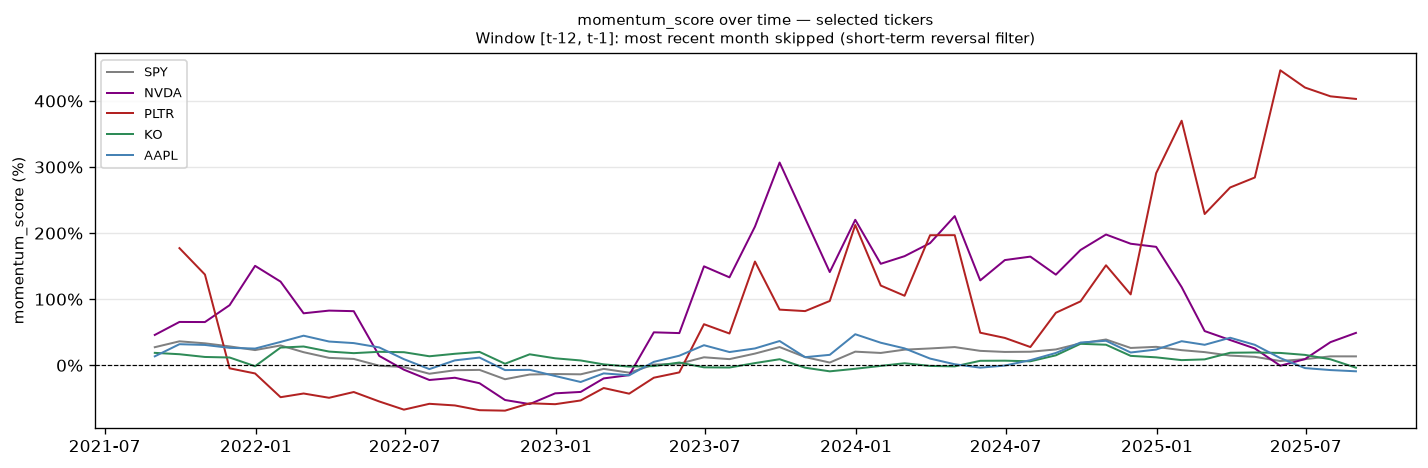

In [9]:
FOCUS  = ["SPY", "NVDA", "PLTR", "KO", "AAPL"]
colors = ["gray", "purple", "firebrick", "seagreen", "steelblue"]

fig, ax = plt.subplots(figsize=(12, 4))
for ticker, color in zip(FOCUS, colors):
    ts = mom[mom["ticker"] == ticker].set_index("date")["momentum_score"]
    ax.plot(ts.index, ts * 100, label=ticker, color=color, linewidth=1.2)

ax.axhline(0, color="black", linestyle="--", linewidth=0.7)
ax.set_title(
    "momentum_score over time — selected tickers\n"
    "Window [t-12, t-1]: most recent month skipped (short-term reversal filter)",
    fontsize=9,
)
ax.set_ylabel("momentum_score (%)", fontsize=9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("momentum_score_time_series.png", bbox_inches="tight")
plt.show()

## 9 · Quality checklist

| Check | Status |
|---|---|
| Window is `[t-12, t-1]` — most recent month skipped; stated in docstring | ✓ |
| `momentum_score` is NOT described as a proxy anywhere | ✓ |
| Rebalance dates come from shared `get_rebalance_dates()` | ✓ |
| Exclusion pattern identical to Task 1 — explained (both anchored at t-12) | ✓ |
| Momentum direction documented: high score = winner, not inverted | ✓ |
| Manual spot-check: AAPL, SPY, PLTR at 2025-08-31 match function output (np.isclose) | ✓ |
| PLTR sanity check: rank 1 on momentum, rank 51 on value — confirmed opposite ends | ✓ |
| Notebook runs top-to-bottom with Restart Kernel & Run All | ✓ |